## (0) Settings and Functions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../../data/feat/play_store_reviews_with_features.csv")

df['TEXT_LEMMA'] = (
    df['TEXT_LEMMA']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

df = df[df["EMOTION"] != "surprise"]

print(df.shape)
df.head(3)

(3006, 17)


,UNCLEAN_TEXT,EMOTION,BASE_TEXT,content,SENTIMENT,TEXT_LEMMA,letter_count,avg_letter_per_word,words_per_sentence,avg_syllables_per_word,reading_time,mean_verbs_per_word,mean_auxiliaries_per_word,mean_auxiliaries_per_sentence,flesch_portuguese,mean_unique_word_length,mean_char_repetition_per_word
0,app shope razoá apes fácil utiliz apresent alg...,sadness,app shope razoa apes facil utiliz apresent alg...,app shope razoá apes fácil utiliz apresent alg...,positive,app shope razoa apes facil utiliz apresent alg...,226.0,4.808511,47.0,1.595745,3.31994,0.148936,0.021277,0.333333,62.226383,4.829268,0.0
1,app bem otimiz fácil visual produt ped rastrei...,sadness,app bem otimiz facil visual produt ped rastrei...,app bem otimiz fácil visual produt ped rastrei...,positive,app bem otimiz facil visual produt ped rastrar...,220.0,4.888889,45.0,1.711111,3.23180,0.177778,0.000000,0.000000,56.000000,4.945946,0.0
2,app bom prát fácil entend porém algum vend man...,sadness,app bom prat facil entend porem algum vend man...,app bom prát fácil entend porém algum vend man...,positive,app bom prat facil entend porem algum vend man...,159.0,4.184211,38.0,1.473684,2.33571,0.157895,0.000000,0.000000,80.374737,4.242424,0.0


In [3]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        'f1_micro': 'f1_micro',
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_macro_scores = results['test_f1_macro']
    f1_weighted_scores = results['test_f1_weighted']
    f1_micro_scores = results['test_f1_micro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_macro_scores.mean(),   f1_macro_scores.std(),   f1_macro_scores),
        "F1_weighted":   (f1_weighted_scores.mean(),   f1_weighted_scores.std(),   f1_weighted_scores),
        "F1_micro":   (f1_micro_scores.mean(),   f1_micro_scores.std(),   f1_micro_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.3, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

## (1) Predict SMOTE

In [4]:
text_feature = "TEXT_LEMMA"

numerical_features = [
    'letter_count', 'avg_letter_per_word',
    'words_per_sentence', 'avg_syllables_per_word', 'reading_time',
    'mean_verbs_per_word', 'mean_auxiliaries_per_word',
    'mean_auxiliaries_per_sentence', 'flesch_portuguese',
    'mean_unique_word_length', 'mean_char_repetition_per_word'
]

cols_input = [text_feature] + numerical_features

X = df[cols_input]

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)

print(X_train.shape, X_dev.shape, X_test.shape)

(2104, 12) (451, 12) (451, 12)


In [5]:
models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    # "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    preprocessor = ColumnTransformer(
        transformers=[
            ('bow', CountVectorizer(), text_feature),
            ('scaler', StandardScaler(), numerical_features)
        ],
        remainder='drop'
    )

    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_train, y_train, n_splits=5, n_repeats=6)

    # plotar_learning_curve(clone(pipe), X_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_weighted_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)


Running model: LogisticRegression

Running model: RidgeClassifier

Running model: LinearSVC

Running model: XGBClassifier
Best model: XGBClassifier


In [6]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/feat/feat_08_PlayStoreReviews_BoW.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro
LogisticRegression,0.5694 ± 0.02,0.4609 ± 0.0487,0.4595 ± 0.0299,0.4551 ± 0.0306,0.5665 ± 0.0197,0.5694 ± 0.02
RidgeClassifier,0.4729 ± 0.0185,0.3722 ± 0.0496,0.3902 ± 0.0267,0.3663 ± 0.0236,0.4774 ± 0.0178,0.4729 ± 0.0185
LinearSVC,0.5256 ± 0.0202,0.4161 ± 0.03,0.4161 ± 0.0266,0.4134 ± 0.0259,0.5239 ± 0.0197,0.5256 ± 0.0202
XGBClassifier,0.5908 ± 0.0189,0.4668 ± 0.0363,0.4195 ± 0.0247,0.4318 ± 0.0279,0.5813 ± 0.0192,0.5908 ± 0.0189


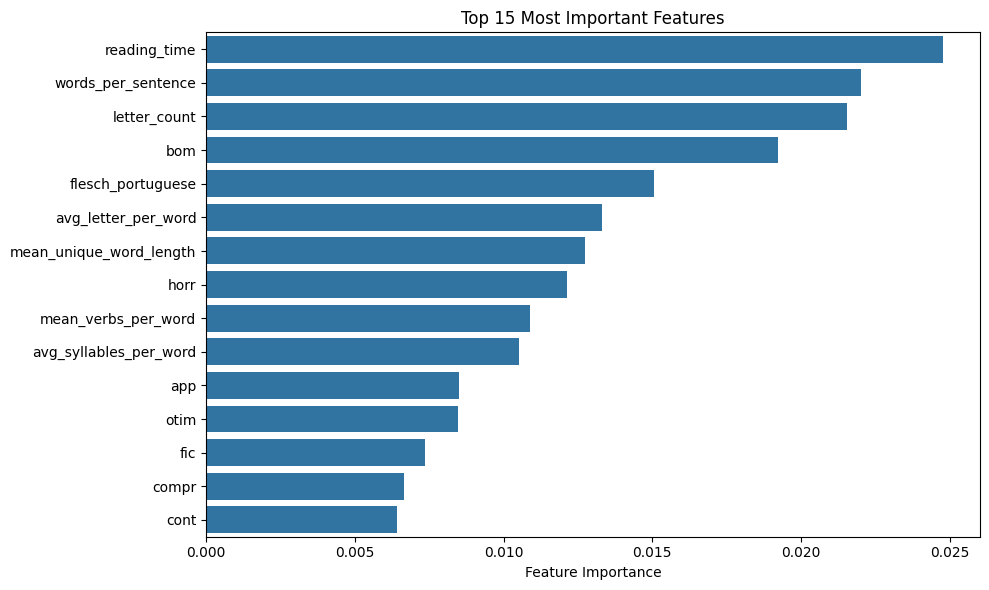

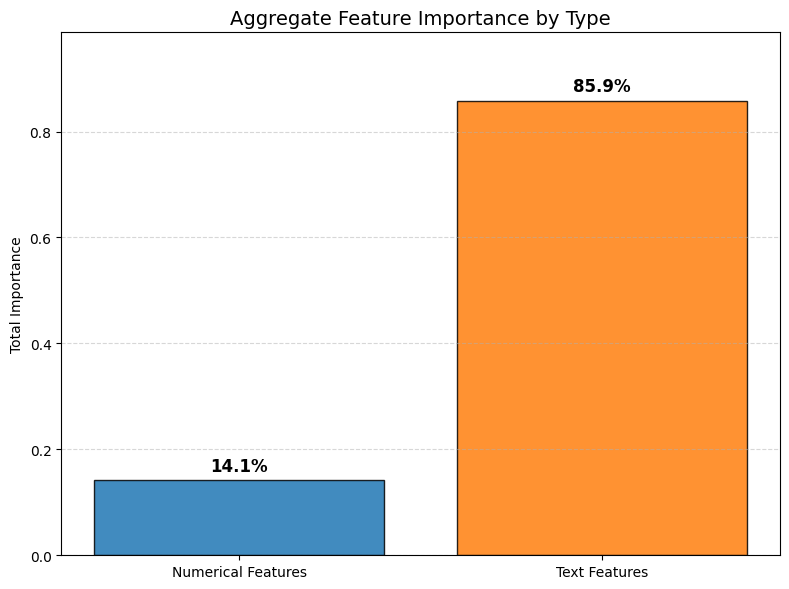

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('bow', CountVectorizer(), text_feature),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

pipe_rf = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)

preprocessor = pipe_rf.named_steps["preprocessor"]
model = pipe_rf.named_steps["model"]

bow = preprocessor.named_transformers_["bow"]
bow_features = bow.get_feature_names_out()

num_features = numerical_features

all_feature_names = np.concatenate([
    bow_features,
    num_features
])

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top15 = feat_imp.head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top15,
    x="importance",
    y="feature",
)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.3f}")
plt.title("Top 15 Most Important Features", fontsize=12)
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

bow_set = set(bow_features)
feat_imp["type"] = feat_imp["feature"].apply(
    lambda f: "Text Features" if f in bow_set else "Numerical Features"
)

agg_imp = (
    feat_imp
    .groupby("type")["importance"]
    .sum()
    .reset_index()
)
agg_imp["percentage"] = (
    agg_imp["importance"] / agg_imp["importance"].sum()
)

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e'] 
bars = plt.bar(
    agg_imp["type"],
    agg_imp["importance"],
    color=colors,
    alpha=0.85,
    edgecolor="black"
)

for bar, perc in zip(bars, agg_imp["percentage"]):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{perc:.1%}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Aggregate Feature Importance by Type", fontsize=14)
plt.ylabel("Total Importance")
plt.xlabel("")
plt.ylim(0, agg_imp["importance"].max() * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## (2) Significance Tests

In [8]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 69.9200
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000001,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.002766,0.002766,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000039,0.000078,True
RidgeClassifier,XGBClassifier,0.000000,0.000000,True


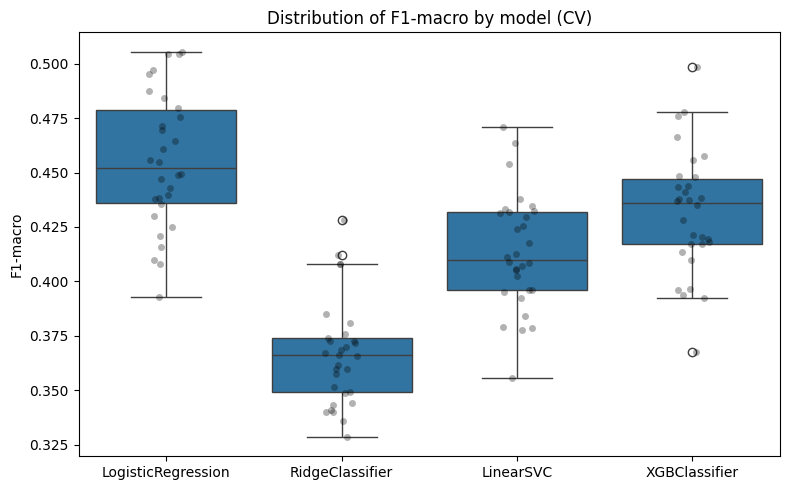

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()